In [36]:
from scipy.stats import norm
from scipy.optimize import fsolve
print("p = ", norm.cdf(6, 3, 5) - norm.cdf(2, 3, 5))
f = lambda c: norm.cdf(2*c, 3, 5) - norm.cdf(-3*c, 3, 5) - 0.6
print("c = ", fsolve(f, 0))

p =  0.3050065916890295
c =  [2.29103356]


上alpha分位数分别为 [3.09023231 2.5758293  2.32634787 1.95996398 1.64485363 1.28155157]


<>:14: SyntaxWarning: invalid escape sequence '\$'
<>:14: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_860/163449538.py:14: SyntaxWarning: invalid escape sequence '\$'
  text(1.9, 0.07, "\\leftarrow\\alpha\$=0.1")


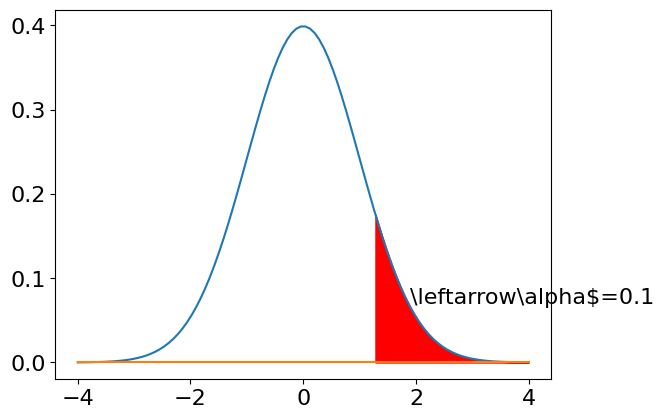

In [37]:
from scipy.stats import norm
from pylab import plot, fill_between, show, text, savefig, rc
from numpy import array, linspace, zeros
alpha = array([0.001, 0.005, 0.01, 0.025, 0.05, 0.10])
za = norm.ppf(1-alpha, 0, 1)    # 求上$\alpha$分位数
print("上alpha分位数分别为", za)
x = linspace(-4, 4, 100); y = norm.pdf(x, 0, 1)
rc('font', size = 16)#; #rc('text', usetex = True)
plot(x, y)
x2 = linspace(za[-1], 4, 100); y2 = norm.pdf(x2)
y1 = [0] * len(x2)
fill_between(x2, y1, y2, color = 'r')   # y1, y2之间填充
plot([-4, 4], [0, 0])
text(1.9, 0.07, "\\leftarrow\\alpha\$=0.1")
# savefig("figure4_2.png", dpi = 500)
show()

In [38]:
from scipy.stats import binom
n, p = 20, 0.8
print("期望和方差分布为: ", binom.stats(n, p))

期望和方差分布为:  (np.float64(16.0), np.float64(3.1999999999999975))


In [39]:
from scipy.stats import binom
n, p = 20,  0.8
mean, variance, skewness, kurtosis = binom.stats(n, p, moments='mvsk')
print("所求的数字特征: ", binom.stats(n, p, moments = 'mvsk'))

所求的数字特征:  (np.float64(16.0), np.float64(3.1999999999999975), np.float64(-0.3354101966249686), np.float64(0.012500000000000178))


In [40]:
from numpy import reshape, hstack, mean, median, ptp, var, std, cov, corrcoef
import pandas as pd
df = pd.read_excel("Pdata4_6_1.xlsx", header = None)
a = df.values
h = a[:, ::2]
w = a[:, 1::2]
h = reshape(h, (-1, 1))
w = reshape(w, (-1, 1))
hw = hstack([h, w])
print([mean(h), median(h), ptp(h), var(h), std(h)])
# 计算均值,中位数,极差,方差,标准差
print("协方差为:{}\n相差系数为:{}".format(cov(hw.T)[0,1], corrcoef(hw.T)[0,1]))

FileNotFoundError: [Errno 2] No such file or directory: 'Pdata4_6_1.xlsx'

In [ ]:
from numpy import reshape, c_
import pandas as pd
df = pd.read_excel("Pdata4_6_1.xlsx", header = None)
a = df.values; h1 = a[:, ::2]; w1 = a[:, 1::2]
h2 = reshape(h1, (-1, 1))
w2 = reshape(w1, (-1, 1))
df2 = pd.DataFrame(c_[h2, w2], columns = ["身高","体重"]) # 构造数据框
print("求得的描述统计量如下: \n", df2.describe())
print("偏度为: \n", df2.skew())
print("峰度为: \n", df2.kurt())
print("分位数为: \n", df.quantile(0.9))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

a = np.loadtxt("Pdata4_9.txt")
b = a.T # 转置成两列的数据

plt.rc('font', size = 16)
plt.rc('font', family = 'SimHei')
plt.boxplot(b, labels = ['女子', '男子'])

plt.savefig('figure4_9.png', dpi = 500)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

a = np.loadtxt("Pdata4_6.txt")
h = a[:, ::2]
w = a[:, 1::2]
h = np.reshape(h, (-1, 1))
w = np.reshape(w, (-1, 1))
hw = np.hstack(h, w)        # 组合

plt.rc('font', size = 16)
plt.rc('font', family = 'SimHei')
plt.boxplot(hw, labels = ["身高", "体重"])

plt.savefig("figure4_10.png", dpi = 500)
plt.show()

In [ ]:
# 程序文件4_15.py
import numpy as np
from statsmodels.stats.weightstats import ztest
sigma = 0.015
a = np.array([0.497, 0.0506, 0.518, 0.524, 0.498, 0.511, 0.520, 0.515, 0.512])
tstat1, pvalue = ztest(a, value = 0.5)   # 计算T统计量的观测值和p值
tstat2 = tstat1 * a.std(ddof=1) / sigma
print('t值为: ', round(tstat1, 4))
print('z值为: ', round(tstat2, 4))
print('p值为: ', round(pvalue, 4))

t值为:  -0.7669
z值为:  -7.8756
p值为:  0.4431


In [ ]:
import numpy as np
from statsmodels.stats.weightstats import ztest
a = np.array([3.25, 3.27, 3.24, 3.26, 3.24])
tstat, pvalue = ztest(a, value = 3.25)
print('检验统计量为: ', tstat)
print('p值为: ', pvalue)

检验统计量为:  0.34299717028498317
p值为:  0.7316005889599273


In [ ]:
import numpy as np
from statsmodels.stats.weightstats import ztest
a = np.array([16, 25, 21, 20, 23, 21, 19, 15, 13, 23, 17, 20, 29, 18, 22, 16, 22])
tstat, pvalue = ztest(a, value = 21, alternative = 'smaller')
print('检验统计量为: ', tstat)
print('p值为', pvalue)

检验统计量为:  -1.0348266239966402
p值为 0.15037494342517732


In [ ]:
import numpy as np
from statsmodels.stats.weightstats import ttest_ind
a = np.array([0.225, 0.262, 0.217, 0.240, 0.230, 0.229, 0.235, 0.217])
b = np.array([0.209, 0.205, 0.196, 0.210, 0.202, 0.207, 0.224, 0.223, 
              0.220, 0.201])
tstat, pvalue, df = ttest_ind(a, b, value = 0, usevar = 'pooled')
print('检验统计量：', tstat)
print('p值为：', pvalue)
print('自由度为：', df)

检验统计量： 3.7035535443338206
p值为： 0.003156058892529494
自由度为： 11.671039115678873


In [ ]:
import numpy as np
from scipy.stats import norm

a = np.loadtxt("Pdata4_6_2.txt")
h = a[:, ::2]
h = h.flatten()
mu = np.mean(h)
s = np.std(h)

print("样本均值和标准差: ", [mu, s])
print("极大似然估计值：", norm.fit(h))

In [ ]:
from numpy import array, sqrt
from scipy.stats import t

a = array([506, 508, 499, 503, 504, 510, 497, 512, 514, 505, 493, 496, 506,
           502, 509, 496])
mu = a.mean()
s = a.std(ddof = 1)
print(mu, s)
alpha = 0.05
n = len(a)

val = (mu-s/sqrt(n)*t.ppf(1-alpha/2, n-1), mu+s/sqrt(n)*t.ppf(1-alpha/2, n-1))
print("置信区间： ", val)

503.75 6.202150164795002
置信区间：  (np.float64(500.44510746243924), np.float64(507.05489253756076))


In [ ]:
import numpy as np
import scipy.stats as ss
# from scipy import stats

a = np.array([506, 508, 499, 503, 504, 510, 497, 512, 514, 505, 493, 496, 506,
           502, 509, 496])
alpha = 0.95
df = len(a) - 1
ci = ss.t.interval(alpha, df, loc = a.mean(), scale = ss.sem(a))

print("置信区间为： ", ci)


置信区间为：  (np.float64(500.44510746243924), np.float64(507.05489253756076))


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as ss

n = 50; k = 8
a = np.loadtxt("Pdata4_20.txt")
a = a.flatten()
mu = a.mean()
s = a.std()
print("均值为: ", mu)
print("标准差为: ", s)
print("最大值为: ", a.max())
print("最小值为: ", a.min())

bins = np.array([14.2, 14.625, 14.8375, 15.05, 15.2625, 15.475, 15.9])# np.linspace(14.2, 15.9, 7)
h = plt.hist(a, bins) #H?
f = h[0]; x = h[0]  # 提取各个小区间的频数，和小区间端点的取值
dp = np.diff(p)     # 计算各个小区间取值的理论概率(p?)
dp[0] = ss.norm.cdf(x[1], mu, s)
dp[-1] = 1 - ss.norm.cdf(x[-2], mu, s)
print("各个小区间的理论概率为: ", dp)
cha = (n2 - n*dp)**2/(n*dp)     # 应该是f吧，哪来的n2
st = cha.sum()    # 计算卡方统计量的观察值
bd = ss.chi2.pdf(0.95, k-5) # 计算上α分位数and软编码k-5

print("统计量为: {}, 临界值为: {}".format(st, bd))

In [ ]:
import pandas as pd

a = pd.read_excel("Pdata4_26_1.xlsx", index_col = None)
# print(a)
# a = a.drop(a.columns[0], axis = 1)
# print('\n',a)
print("是否存在重复观测: ", any(a.duplicated()))

a.drop_duplicates(inplace = True)     # inplace = True时，直接删除a中的重复数据
f = pd.ExcelWriter('Pdata4_26_2.xlsx')  # 创建文件对象
a.to_excel(f)                           # 把a写入新的excel文件中
f.close()


是否存在重复观测:  True


In [41]:
from pandas import read_excel
a = read_excel("Pdata2_33.xlsx", usecols = range(1, 4))
b1 = a.dropna()                     # 删除所有缺失值
b2 = a.dropna(axis = 1, thresh = 9) # 删除有效数据少于9的列
b3 = a.drop('用户B', axis = 1)      # 删除用户b的数据
print(b1, '\n-----------\n', b2, '\n-----------\n', b3)

      用户A     用户B      用户C
0  235.83  324.03  473.320
1  236.27  325.63  515.450
2  238.05  328.08  517.090
6  237.41  391.26  516.230
8  237.61  388.02  435.350
9  238.03  206.43  487.675 
-----------
       用户A     用户B
0  235.83  324.03
1  236.27  325.63
2  238.05  328.08
3  235.90     NaN
4  236.76  268.82
5     NaN  404.04
6  237.41  391.26
7  238.65  380.81
8  237.61  388.02
9  238.03  206.43 
-----------
       用户A      用户C
0  235.83  473.320
1  236.27  515.450
2  238.05  517.090
3  235.90  514.890
4  236.76      NaN
5     NaN  486.090
6  237.41  516.230
7  238.65      NaN
8  237.61  435.350
9  238.03  487.675


In [44]:
from pandas import read_excel
a = read_excel("Pdata4_29.xlsx")
b1 = a.fillna(0)                    # 用0填补所有缺失值
b2 = a.fillna(method = 'ffill')     # 用前一行的值填补缺失值 # future
b3 = a.fillna(method = 'bfill')     # 用后一行的值填补缺失值 # 更新换为bfill(),ffill()
b4 = a.fillna(value = {'gender': a.gender.mode()[0],  # 性别用众数替换
                      'age' : a.age.mean(),           # 年龄用均值替换
                      'income' : a.income.median()})  # 收入用中位数替换
print(a, '\n------\n', b1, '\n----------\n', b2, '\n----------\n', b3, '\n----------\n', b4)

        uid regit_date gender   age   income
0  81200457 2016-10-30      M  23.0   6500.0
1  81201135 2016-11-08      M  27.0  10300.0
2  80043782 2016-10-13      F   NaN  13500.0
3  84639281 2017-04-17      M  26.0   6000.0
4  73499801 2016-03-21    NaN   NaN   4500.0
5  72399510 2016-01-18      M  19.0      NaN
6  63881943 2015-10-07      M  21.0  10000.0
7  35442690 2015-04-10      F   NaN   5800.0
8  77638351 2016-07-12      M  25.0  18000.0
9  85200189 2017-05-18      M  22.0      NaN 
------
         uid regit_date gender   age   income
0  81200457 2016-10-30      M  23.0   6500.0
1  81201135 2016-11-08      M  27.0  10300.0
2  80043782 2016-10-13      F   0.0  13500.0
3  84639281 2017-04-17      M  26.0   6000.0
4  73499801 2016-03-21      0   0.0   4500.0
5  72399510 2016-01-18      M  19.0      0.0
6  63881943 2015-10-07      M  21.0  10000.0
7  35442690 2015-04-10      F   0.0   5800.0
8  77638351 2016-07-12      M  25.0  18000.0
9  85200189 2017-05-18      M  22.0      0.0 


/tmp/ipykernel_860/3051217484.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  b2 = a.fillna(method = 'ffill')     # 用前一行的值填补缺失值
/tmp/ipykernel_860/3051217484.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  b3 = a.fillna(method = 'bfill')     # 用后一行的值填补缺失值


In [46]:
from pandas import read_excel
import numpy as np
a = read_excel("Pdata4_29.xlsx")
b = a.fillna(value = {'gender': a.gender.mode()[0], # 性别用众数替换
            'age': a.age.interpolate(method = 'polynomial', order = 2),  # 年龄用二次多项式插值替换
            'income': a.income.interpolate()})   # 收入用线性插值替换
print(a, '\n------\n', b)

        uid regit_date gender   age   income
0  81200457 2016-10-30      M  23.0   6500.0
1  81201135 2016-11-08      M  27.0  10300.0
2  80043782 2016-10-13      F   NaN  13500.0
3  84639281 2017-04-17      M  26.0   6000.0
4  73499801 2016-03-21    NaN   NaN   4500.0
5  72399510 2016-01-18      M  19.0      NaN
6  63881943 2015-10-07      M  21.0  10000.0
7  35442690 2015-04-10      F   NaN   5800.0
8  77638351 2016-07-12      M  25.0  18000.0
9  85200189 2017-05-18      M  22.0      NaN 
------
         uid regit_date gender        age   income
0  81200457 2016-10-30      M  23.000000   6500.0
1  81201135 2016-11-08      M  27.000000  10300.0
2  80043782 2016-10-13      F  27.875282  13500.0
3  84639281 2017-04-17      M  26.000000   6000.0
4  73499801 2016-03-21      M  21.748310   4500.0
5  72399510 2016-01-18      M  19.000000   7250.0
6  63881943 2015-10-07      M  21.000000  10000.0
7  35442690 2015-04-10      F  23.939144   5800.0
8  77638351 2016-07-12      M  25.000000  1800

In [48]:
from scipy.optimize import linprog
c = [-1, 4]
A = [[-3, 1], [1, 2]]
B = [6, 4]
bounds = ((None, None), (-3, None))

res = linprog(c, A, B, None, None, bounds)
print("目标函数的最小值为", res.fun)
print("最优解为", res.x)

目标函数的最小值为 -22.0
最优解为 [10. -3.]


In [52]:
from scipy.optimize import linprog

c = [-1, 2, 3]
A = [[-2, 1, 1], [3, -1, -2]]
B = [[9], [-4]]
Aeq = [[4, -2, -1]]
beq = [-6]
LB = [-10, 0, None]
UB = [None]*len(c)  #生成三个None的列表
bound = tuple(zip(LB, UB))  # 生成决策向量的元组
# print(bound)

res = linprog(c, A, B, Aeq, beq, bound)
print("目标函数的最小值为：", res.fun)
print("最优解为：", res.x)

((-10, None), (0, None), (None, None))
目标函数的最小值为： 0.399999999999999
最优解为： [-1.6  0.  -0.4]


In [53]:
from scipy.optimize import linprog

c = [110, 120, 130, 110, 115, -150]
A = [[1, 1, 0, 0, 0, 0], [0, 0, 1, 1, 1, 0], [8.8, 6.1, 2.0, 4.2, 5.0, -6],
     [-8.8, -6.1, -2.0, -4.2, -5.0, 3]]
b = [[200], [250], [0], [0]]
Aeq = [[1, 1, 1, 1, 1, -1]]
beq = [0]

res = linprog(c, A, b, Aeq, beq)
print("目标函数最小值为：", res.fun)
print("最优解为：", res.x)

目标函数最小值为： -17592.592592592595
最优解为： [159.25925926  40.74074074   0.         250.           0.
 450.        ]


In [55]:
# 程序文件5_4.py
import numpy as np
from cvxopt import matrix, solvers

c = matrix([-4., -5])
A = matrix([[2., 1], [1, 2], [-1, 0], [0, 1]]).T
b = matrix([3., 3, 0, 0])

sol = solvers.lp(c, A, b)
print("最优解为：\n", sol['x'])
print("最优值为：", sol['primal objective'])

     pcost       dcost       gap    pres   dres   k/t
 0: -8.1000e+00 -1.5300e+01  2e+01  9e-01  8e-01  1e+00
 1: -6.9383e+00 -7.9663e+00  2e+00  2e-01  1e-01  4e-01
 2: -6.0098e+00 -6.0331e+00  4e-02  3e-03  3e-03  4e-03
 3: -6.0001e+00 -6.0003e+00  4e-04  3e-05  3e-05  4e-05
 4: -6.0000e+00 -6.0000e+00  4e-06  3e-07  3e-07  4e-07
 5: -6.0000e+00 -6.0000e+00  4e-08  3e-09  3e-09  4e-09
Optimal solution found.
最优解为：
 [ 1.50e+00]
[ 5.41e-09]

最优值为： -6.00000000978055


In [3]:
# 程序文件Pex5_5.py
import numpy as np
from cvxopt import matrix,solvers

c = matrix([2., 1])
A = matrix([[-1., 1], [-1, -1], [1, -2], [0, -1]]).T  # 注意A矩阵需要转置，从2行4列转为(4,2)
b = matrix([1., -2, 4, 0])
Aeq = matrix([1., 2], (1, 2))    # Aeq为行向量
beq = matrix(3.5)   # 不需要[]列表形式

sol = solvers.lp(c, A, b, Aeq, beq)
print("目标解为：\n", sol['x'])
print("目标值为：", sol['primal objective'])


     pcost       dcost       gap    pres   dres   k/t
 0:  5.5556e+00  1.2222e+00  1e+01  0e+00  2e+00  1e+00
 1:  4.6038e+00  3.7995e+00  2e+00  1e-16  4e-01  2e-01
 2:  2.5229e+00  2.4639e+00  2e-01  2e-16  4e-02  4e-02
 3:  2.5002e+00  2.4997e+00  2e-03  1e-16  4e-04  4e-04
 4:  2.5000e+00  2.5000e+00  2e-05  3e-16  4e-06  4e-06
 5:  2.5000e+00  2.5000e+00  2e-07  2e-16  4e-08  4e-08
Optimal solution found.
目标解为：
 [ 5.00e-01]
[ 1.50e+00]

目标值为： 2.5000000246110483


In [ ]:
import cvxpy as cp
import numpy as np
import pandas as pd

d1 = pd.read_excel("Pdata5_6.xlsx", header = None)
d2 = d1.values
c = d2[:-1, :-1]
d = d2[-1. :-1].reshape(-1, 1)
e = d2[:-1, -1].reshape(-1, 1)
x = cp.Variable(6, 8)

obj = cp.Minimize(cp.sum(cp.multiply(c, x)))    #构造目标函数
con = [cp.sum(x, axis = 1, keepdims = True) <= e,
        cp.sum(x, axis = 0, keepdims = True) == d,
        x >= 0]                                 # 构造约束条件
prob = cp.Probelm(obj, con)                     # 构造模型
prob.solve(solver = 'GLPK_MI', verbose = True)  # 求解模型

In [7]:
import cvxpy as cp
from numpy import array

c = array([40, 90])             # 定义目标向量
a = array([[9, 7], [-7, -20]])  # 定义约束矩阵
b = array([56, -70])            # 定义约束条件的右边向量
x = cp.Variable(2, integer = True)  # 定义两个整数决策变量

obj = cp.Minimize(c*x)          # 构造目标函数
cons = [a*x <= b, x >= 0]       # 构造约束条件
prob = cp.Problem(obj, cons)    # 构造问题模型
prob.solve(solver = 'GLPK_MI', verbose = True)  # 求解问题
print("最优值为: ", prob.value)
print("最优解为: \n", x.value)

                                     CVXPY                                     
                                     v1.5.3                                    
(CVXPY) Sep 03 03:58:26 PM: Your problem has 2 variables, 4 constraints, and 0 parameters.
(CVXPY) Sep 03 03:58:26 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Sep 03 03:58:26 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Sep 03 03:58:26 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Sep 03 03:58:26 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Sep 03 03:58:26 PM: Compiling problem (target solver=GLPK_MI).
(C

/home/jason/miniconda3/lib/python3.12/site-packages/cvxpy/expressions/expression.py:650: UserWarning: 
This use of ``*`` has resulted in matrix multiplication.
Using ``*`` for matrix multiplication has been deprecated since CVXPY 1.1.
    Use ``*`` for matrix-scalar and vector-scalar multiplication.
    Use ``@`` for matrix-matrix and matrix-vector multiplication.
    Use ``multiply`` for elementwise multiplication.
This code path has been hit 5 times so far.

  warnings.warn(msg, UserWarning)
/home/jason/miniconda3/lib/python3.12/site-packages/cvxpy/expressions/expression.py:650: UserWarning: 
This use of ``*`` has resulted in matrix multiplication.
Using ``*`` for matrix multiplication has been deprecated since CVXPY 1.1.
    Use ``*`` for matrix-scalar and vector-scalar multiplication.
    Use ``@`` for matrix-matrix and matrix-vector multiplication.
    Use ``multiply`` for elementwise multiplication.
This code path has been hit 6 times so far.

  warnings.warn(msg, UserWarning)


(CVXPY) Sep 03 03:58:26 PM: Finished problem compilation (took 1.694e-01 seconds).
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
(CVXPY) Sep 03 03:58:26 PM: Invoking solver GLPK_MI  to obtain a solution.
      0: obj =   2.700000000e+02  infeas =  6.250e-01 (0)
*     1: obj =   3.150000000e+02  infeas =  0.000e+00 (0)
+     1: mip =     not found yet >=              -inf        (1; 0)
Solution found by heuristic: 360
+     2: >>>>>   3.500000000e+02 >=   3.500000000e+02   0.0% (1; 0)
+     2: mip =   3.500000000e+02 >=     tree is empty   0.0% (0; 1)
-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------
(CVXPY) S

In [8]:
from scipy.optimize import minimize
from numpy import ones

def obj(x):
    x1, x2, x3 = x
    return (2+x1)/(1+x2)-3*x1+4*x3
LB = [0.1]*3
UB = [0.9]*3
bound = tuple(zip(LB, UB))                      # 生成决策向量界限的元组

res = minimize(obj, ones(3), bounds = bound)    # 第二个参数为初值
print(res.fun, '\n', res.success, '\n', res.x)  # 输出最优值、求解状态、最优解

-0.7736842105263159 
 True 
 [0.9 0.9 0.1]


In [13]:
# 程序文件Pex6_5.py
from scipy.optimize import minimize
import numpy as np

c1 = np.array([1, 1, 3, 4, 2])
c2 = np.array([-8, -2, -3, -1, -2])
A = np.array([[1, 1, 1, 1, 1], [1, 2, 2, 1, 6],
                 [2, 1, 6, 0, 0], [0, 0, 1, 1, 5]])
b = np.array([400, 800, 200, 200])

obj = lambda x: np.dot(-c1, x**2) + np.dot(-c2, x)
cons = {'type': 'ineq', 'fun': lambda x:b-A@x}
bd = [(0, 99) for i in range(A.shape[1])]
print(bd, '\n\n')
res = minimize(obj, np.ones(5)*90, constraints = cons, bounds = bd)
print(res)          # 输出解的信息

[(0, 99), (0, 99), (0, 99), (0, 99), (0, 99)] 


 message: Optimization terminated successfully
 success: True
  status: 0
     fun: -51629.93000063647
       x: [ 5.050e+01  9.900e+01  0.000e+00  9.900e+01  2.020e+01]
     nit: 4
     jac: [-9.300e+01 -1.960e+02  3.000e+00 -7.910e+02 -7.880e+01]
    nfev: 20
    njev: 3


In [16]:
import numpy as np
from cvxopt import matrix, solvers

n = 3
P = matrix(0., (n, n))
P[::n+1] = [3, 2, 1.7]
q = matrix([3, -8.2, -1.95])
A = matrix([[1., 0, 1], [-1, 2, 0], [0, 1, 2]]).T
b = matrix([2., 2, 3])
Aeq = matrix(1., (1, n))
beq = matrix(3.)

s = solvers.qp(P, q, A, b, Aeq, beq)
print("最优解为：", s['x'])
print("最优值为：", s['primal objective'])

     pcost       dcost       gap    pres   dres
 0: -1.3148e+01 -4.4315e+00  1e+01  1e+00  9e-01
 1: -6.4674e+00 -7.5675e+00  1e+00  3e-16  4e-16
 2: -7.1538e+00 -7.1854e+00  3e-02  1e-16  2e-15
 3: -7.1758e+00 -7.1761e+00  3e-04  2e-16  2e-15
 4: -7.1760e+00 -7.1760e+00  3e-06  1e-16  2e-15
Optimal solution found.
最优解为： [ 8.00e-01]
[ 1.40e+00]
[ 8.00e-01]

最优值为： -7.1759977687772745


In [20]:
import numpy as np
import cvxpy as cp

c1 = np.array([1, 1, 3, 4, 2])
c2 = np.array([-8, -2, -3, -1, -2])
a = np.array([[1, 1, 1, 1, 1], [1, 2, 2, 1, 6], [2, 1, 6, 0, 0], [0, 0, 1, 1, 5]])
b = np.array([400, 800, 200, 200])

x = cp.Variable(5, integer = True)
obj = cp.Minimize(c1*x**2+c2*x)
con = [0 <= x, x <= 99, a*x <= b]

prob = cp.Problem(obj, con)
prob.solve()
print("最优值为: ", prob.value)
print("最优解为: ", x.value)

/home/jason/miniconda3/lib/python3.12/site-packages/cvxpy/expressions/expression.py:650: UserWarning: 
This use of ``*`` has resulted in matrix multiplication.
Using ``*`` for matrix multiplication has been deprecated since CVXPY 1.1.
    Use ``*`` for matrix-scalar and vector-scalar multiplication.
    Use ``@`` for matrix-matrix and matrix-vector multiplication.
    Use ``multiply`` for elementwise multiplication.
This code path has been hit 10 times so far.

  warnings.warn(msg, UserWarning)
/home/jason/miniconda3/lib/python3.12/site-packages/cvxpy/expressions/expression.py:650: UserWarning: 
This use of ``*`` has resulted in matrix multiplication.
Using ``*`` for matrix multiplication has been deprecated since CVXPY 1.1.
    Use ``*`` for matrix-scalar and vector-scalar multiplication.
    Use ``@`` for matrix-matrix and matrix-vector multiplication.
    Use ``multiply`` for elementwise multiplication.
This code path has been hit 11 times so far.

  warnings.warn(msg, UserWarning)


SolverError: Either candidate conic solvers (['GLPK_MI', 'SCIPY']) do not support the cones output by the problem (SOC, NonNeg), or there are not enough constraints in the problem.

In [22]:
from sympy.abc import x
from sympy import diff, dsolve, simplify, Function

y = Function('y')
eq = diff(y(x), x, 2) + 2*diff(y(x), x, 1) + 2*y(x) # 定义方程
con = {y(0): 0, diff(y(x), x).subs(x, 0): 1}        # 定义初值条件
y = dsolve(eq, ics = con)
print(simplify(y))

Eq(y(x), exp(-x)*sin(x))
Eq(y(x), exp(-x)*sin(x))


In [23]:
# 程序文件Pex8_2.py
from sympy.abc import x
from sympy import Function, dsolve, diff, sin

y = Function('y')
eq = diff(y(x), x, 2) + 2*diff(y(x), x) + 2*y(x) - sin(x)   # 定义方程
con = {y(0): 0, diff(y(x), x).subs(x, 0): 1}                # 定义初值条件
y = dsolve(eq, ics = con)

print(y)

Eq(y(x), (6*sin(x)/5 + 2*cos(x)/5)*exp(-x) + sin(x)/5 - 2*cos(x)/5)


In [24]:
# 程序文件Pex8_3.py
import sympy as sp
t = sp.symbols('t')
x1, x2, x3 = sp.symbols('x1, x2, x3', cls = sp.Function)
eq = [x1(t).diff(t) - 2*x1(t) + 3*x2(t) - 3*x3(t),
      x2(t).diff(t) - 4*x1(t) + 5*x2(t) - 3*x3(t),
      x3(t).diff(t) - 4*x1(t) + 4*x2(t) - 2*x3(t)]
con = {x1(0): 1, x2(0): 2, x3(0): 3}
s = sp.dsolve(eq, ics = con)
print(s)

[Eq(x1(t), 2*exp(2*t) - exp(-t)), Eq(x2(t), 2*exp(2*t) - exp(-t) + exp(-2*t)), Eq(x3(t), 2*exp(2*t) + exp(-2*t))]


In [28]:
# 程序文件PEx8_3_2.py
import sympy as sp

t = sp.symbols('t')
x1, x2, x3 = sp.symbols('x1:4', cls = sp.Function)
x = sp.Matrix([x1(t), x2(t), x3(t)])
A = sp.Matrix([[2, -3, 3], [4, -5, 3], [4, -4, 2]])
eq = x.diff(t)-A*x
s = sp.dsolve(eq, ics = {x1(0): 1, x2(0): 2, x3(0):(3)})

print(s)

[Eq(x1(t), 2*exp(2*t) - exp(-t)), Eq(x2(t), 2*exp(2*t) - exp(-t) + exp(-2*t)), Eq(x3(t), 2*exp(2*t) + exp(-2*t))]


In [30]:
# 程序文件8_4.py
from scipy.integrate import odeint
from numpy import arange

dy = lambda y, x: -2*y + x**2 + 2*x
x = arange(1, 10.5, 0.5)
sol = odeint(dy, 2, x)

print("x = {}\n对应的数值解y = {}".format(x, sol.T))

x = [ 1.   1.5  2.   2.5  3.   3.5  4.   4.5  5.   5.5  6.   6.5  7.   7.5
  8.   8.5  9.   9.5 10. ]
对应的数值解y = [[ 2.          2.08484933  2.9191691   4.18723381  5.77289452  7.63342241
   9.75309843 12.12613985 14.75041934 17.62515427 20.75005673 24.12502089
  27.7500077  31.62500278 35.75000104 40.1250004  44.75000015 49.62500006
  54.75000002]]


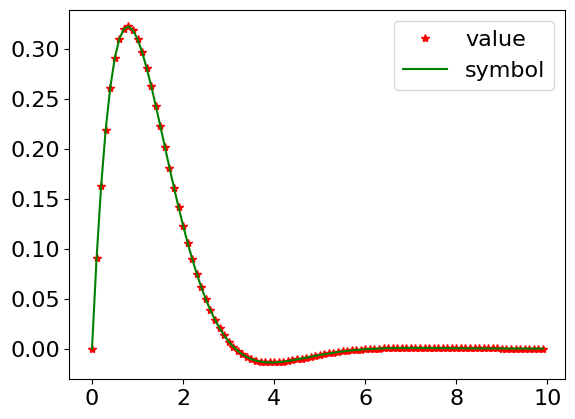

In [1]:
# 程序文件Pex8_5.py
from scipy.integrate import odeint
from sympy.abc import t
import numpy as np
import matplotlib.pyplot as plt

def Pfun(y, x):
    y1, y2 = y
    return [y2, -2*y1 - 2*y2]
x = np.arange(0, 10, 0.1)
sol = odeint(Pfun, [0.0, 1.0], x)

plt.rc('font', size = 16)   
plt.rc('font', family = 'Sima'a')
plt.plot(x, sol[:, 0], 'r*', label = "value")   # 汉字未正常显示，数值解
plt.plot(x, np.exp(-x)*np.sin(x), 'g', label = "symbol")  #符号解曲线
plt.legend()
# plt.savefig("figure8_5.png")
plt.show()

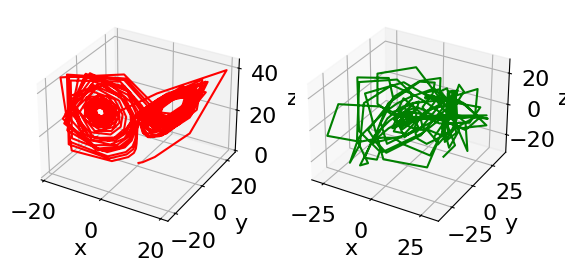

sol1 =  [[ 0.          1.          0.        ]
 [ 0.91203874  2.0919284   0.06245151]
 [ 3.05474722  6.63830807  0.76713643]
 ...
 [ 0.88333489  1.66768276 16.24209293]
 [ 1.8857161   3.28048771 12.73426432]
 [ 4.10264688  7.42619544 11.12259875]] 

 sol1 - sol2 =  [[ 0.00000000e+00 -1.00000000e-04  0.00000000e+00]
 [-9.11636487e-05 -2.08935969e-04 -1.24864278e-05]
 [-3.02425034e-04 -6.49261606e-04 -1.52202288e-04]
 ...
 [ 1.08519621e+01  1.76621198e+01 -3.05404478e+00]
 [ 1.64990856e+01  1.88489769e+01 -2.15616739e+01]
 [ 1.43443201e+01  9.94593284e+00 -2.53861555e+01]]


In [3]:
from scipy.integrate import odeint
import numpy as np
from mpl_toolkits import mplot3d
import matplotlib.pyplot as plt

def lorenz(w, t):
    sigma = 10; rho = 28; beta = 8/3.   # beta不需要控制浮点数吗（书上8/3）
    x, y, z = w
    return np.array([sigma*(y-x), rho*x-y-x*z, x*y-beta*z])
t = np.arange(0, 50, 0.1)               # 创建时间点
sol1 = odeint(lorenz, [0.0, 1.0, 0.0], t)       # 第一个初值问题求解
sol2 = odeint(lorenz, [0.0, 1.0001, 0.0], t)    # 第二个初值问题求解

plt.rc('font', size = 16) # plt.rc('text', usetex = True)
ax1 = plt.subplot(121, projection = '3d')           # 设置画布
ax1.plot(sol1[:, 0], sol1[:, 1], sol1[:,2], 'r')    # 根据xyz画图
ax1.set_xlabel('x')                                 # 设置标签x
ax1.set_ylabel('y')                                 # 设置标签y
ax1.set_zlabel('z')                                 # 设置标签z

ax2 = plt.subplot(122, projection = '3d')
ax2.plot(sol1[:, 0] - sol2[:, 0], sol1[:, 1] - sol2[:, 1], sol1[:, 2] - sol2[:, 2], 'g')
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_zlabel('z')

plt.savefig("figure8_6.png", dpi = 500)
plt.show()
print("sol1 = ", sol1, '\n\n', 'sol1 - sol2 = ', sol1 - sol2)

In [8]:
import sympy as sp
sp.var('t, k')        # 定义符号变量t, k
u = sp.var('u', cls = sp.Function)          # 定义符号函数
eq = sp.diff(u(t), t) + k * (u(t) - 24)     # 定义方程
uu = sp.dsolve(eq, ics = {u(0): 150})    # 求微分方程的符号解
print(uu)
# print(uu.args[1])

kk = sp.solve(uu, k)    # kk返回值是列表,可能有多个解
k0 = kk[0].subs({t: 10.0, u(t): 100.0})
print(kk, '\t', k0)
u1 = uu.args[1]         # 提出符号表达式
u0 = u1.subs({t: 20, k: k0})    # 代入具体值
print("20分钟后的温度为: ", u0)

Eq(u(t), 24 + 126*exp(-k*t))
24 + 126*exp(-k*t)
[log(126/(u(t) - 24))/t] 	 0.0505548566665147
20分钟后的温度为:  69.8412698412698


In [10]:
import numpy as np

sp.var('h')                     # 定义符号变量
sp.var('t', cls = sp.Function)  # 定义符号函数
g = 9.8

eq = t(h).diff(h) - 10000*sp.pi / 0.62 / sp.sqrt(2*g) * (h**(3/2)-2*h**(1/2))   # 定义方程
t = sp.dsolve(eq, ics = {t(1): 0})
# print(t)
t = sp.simplify(t)

print(t.args[1].n(9))

Eq(t(h), 4578.15127456044*h**(5/2) - 15260.5042485347*h**(3/2) + 10682.3529739743)
-15260.5042*h**1.5 + 4578.15127*h**2.5 + 10682.353


In [11]:
# 程序文件Pex8_9.py
from numpy import array
v0 = array([45, 65, 80])
T0 = 1; L = 4.5; I = 9; mu = 0.7; g = 9.8
T = v0/(2*mu*g)+(I+L)/v0+T0
print(T)

[4.57988338 5.94530164 6.99965379]


In [12]:
import numpy as np
import pandas as pd

a = np.loadtxt("Pdata9_1_1.txt")
R1 = a.copy()
R2 = a.copy()
R3 = a.copy()   # 初始化
# attention: 若 R1 = a,内存地址一样, R1改变时, a也改变

for j in [0, 1, 2, 4, 5]:       # 外循环处理不同指标,内部一句处理该指标的每个值 # 处理极大型
    R1[:, j] = R1[:, j]/np.linalg.norm(R1[:, j])    # 向量归一化
    R2[:, j] = R1[:, j]/max(R1[:, j])
    R3[:, j] = (R3[:, j] - min(R3[:, j]))/(max(R3[:, j] - min(R3[:, j])))
R1[:, 3] = 1 - R1[:, 3]/np.linalg.norm(R1[:, 3])
R2[:, 3] = min(R2[:, 3])/R2[:, 3]
R3[:, 3] = (max(R3[:, 3]) - R3[:, 3])/(max(R3[:, 3] - min(R3[:, 3])))

np.savetxt("Pdata9_1_2.txt", R1)    # 把数据写入文本,供下面使用(?)
np.savetxt("Pdata9_1_3.txt", R2)
np.savetxt("Pdata9_1_4.txt", R3)

DR1 = pd.DataFrame(R1)              # 生成DataFrame类型数据
DR2 = pd.DataFrame(R2)
DR3 = pd.DataFrame(R3)

f = pd.ExcelWriter('Pdata9_1_5.xlsx')   # 创建文件对象
DR1.to_excel(f, "sheet1")           # 把DR1写入Excel文件1号表单,方便做表
DR2.to_excel(f, "sheet2")
DR3.to_excel(f, "sheet3")

f.close()

/tmp/ipykernel_237305/1478736640.py:27: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  DR1.to_excel(f, "sheet1")           # 把DR1写入Excel文件1号表单,方便做表
/tmp/ipykernel_237305/1478736640.py:28: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  DR2.to_excel(f, "sheet2")
/tmp/ipykernel_237305/1478736640.py:29: FutureWarning: Starting with pandas version 3.0 all arguments of to_excel except for the argument 'excel_writer' will be keyword-only.
  DR3.to_excel(f, "sheet3")


In [15]:
# 程序文件 Pex9_2.py
import numpy as np
from scipy.stats import rankdata

# TOPSIS法
a = np.loadtxt("Pdata9_1_3.txt")
cplus = a.max(axis = 0)         # 逐列求最大值
cminus = a.min(axis = 0)        # 逐列求最小值
print("正理想解 = ", cplus, "负理想解 = ", cminus)
d1 = np.linalg.norm(a-cplus, axis = 1)  # 求到正理想解的距离
d2 = np.linalg.norm(a-cminus, axis = 1) # 求到负理想解的距离
print(d1, d2)
f1 = d2/(d1+d2)
print("TOPSIS的评价值为: ", f1)

# 灰色关联度分析
t = cplus - a                   # 计算参考序列与每个序列的差
mmin = t.min()
mmax = t.max()                  # 计算最小差和最大差
rho = 0.5
xs = (mmin+rho*mmax)/(t+rho*mmax)# 计算灰色关联系数
f2 = xs.mean(axis = 1)          # 求每一行的均值-灰色关联度
print("\n关联系数 = ", xs, '\n关联度 = ', f2)   # 显示灰色关联系数和灰色关联度

# 熵值法
[n, m] = a.shape
cs =  a.sum(axis = 0)       # 逐列求和
P = 1/cs * a                # 求特征比重矩阵
e = -(P*np.log(P)).sum(axis = 0)/np.log(n)  # 计算熵值
g = 1 - e                   # 计算差异系数
w = g/sum(g)                # 计算权重
F = P@w                     # 计算各对象评价值
print("\nP={}\n,e={}\n,g={}\n,w={},\nF={}".format(P, e, g, w, F))

# 秩和比法
R = [rankdata(a[:, i]) for i in np.arange(6)]   # 求每一列的秩
R = np.array(R).T                               # 构造秩矩阵
print("\n秩矩阵为: \n", R)
RSR = R.mean(axis = 1)/n
print("RSR = ", RSR)

正理想解 =  [1. 1. 1. 1. 1. 1.] 负理想解 =  [0.72       0.55555556 0.85714286 0.69230769 0.42857143 0.5       ]
[0.59538974 0.83163293 0.48540227 0.685136  ] [0.60245103 0.52529122 0.71826658 0.4144692 ]
TOPSIS的评价值为:  [0.50294751 0.38711907 0.59673105 0.37692547]

关联系数 =  [[0.58823529 0.39130435 0.85714286 0.61111111 0.5        1.        ]
 [1.         1.         0.66666667 0.48148148 0.33333333 0.36363636]
 [0.50505051 0.52427184 1.         1.         1.         0.48780488]
 [0.70422535 0.46153846 0.85714286 0.74074074 0.5        0.36363636]] 
关联度 =  [0.6579656  0.64085297 0.75285454 0.6045473 ]

P=[[0.23529412 0.1875     0.25316456 0.23990158 0.25       0.37037037]
 [0.29411765 0.3375     0.2278481  0.20299364 0.15       0.18518519]
 [0.21176471 0.25       0.26582278 0.29321304 0.35       0.25925926]
 [0.25882353 0.225      0.25316456 0.26389174 0.25       0.18518519]]
,e=[0.99468893 0.98294821 0.99888759 0.9936177  0.97032272 0.96836882]
,g=[0.00531107 0.01705179 0.00111241 0.0063823  0.029

In [17]:
import numpy as np
import pandas as pd

# 参数
p = 55 / 100  # 螺距，转换为米
speed_head = 1  # 龙头速度，单位 m/s
total_sections = 223
lengths = [341 / 100] + [220 / 100] * (total_sections - 2) + [220 / 100]  # 转换为米

time_points = np.arange(0, 301)  # 从0到300秒
positions = []
velocities = []

for t in time_points:
    # 计算当前角度和半径
    angle = (speed_head * t / (2 * np.pi * (p / 2))) * (2 * np.pi)  # 角度
    radius = (t * speed_head) / (2 * np.pi)  # 当前半径

    # 计算各把手位置
    current_positions = []
    for i in range(total_sections):
        # 计算每个把手的位置
        x = (radius + sum(lengths[:i])) * np.cos(angle + i * (2 * np.pi / total_sections))
        y = (radius + sum(lengths[:i])) * np.sin(angle + i * (2 * np.pi / total_sections))
        current_positions.append((x, y))
    
    # 计算速度（假设为恒定速度）
    current_velocities = [(speed_head * np.cos(angle + i * (2 * np.pi / total_sections)), 
                            speed_head * np.sin(angle + i * (2 * np.pi / total_sections))) for i in range(total_sections)]

    positions.append(current_positions)
    velocities.append(current_velocities)

# 保存到 DataFrame
df_positions = pd.DataFrame(positions)
df_velocities = pd.DataFrame(velocities)

# 写入 Excel
with pd.ExcelWriter('result1.xlsx') as writer:
    df_positions.to_excel(writer, sheet_name='Positions', index=False, header = False)
    df_velocities.to_excel(writer, sheet_name='Velocities', index=False)

In [18]:
import numpy as np
import pandas as pd

# 参数初始化
p = 55 / 100  # 螺距
speed_head = 1  # 龙头速度
total_sections = 223
lengths = [341 / 100] + [220 / 100] * (total_sections - 2) + [220 / 100]

# 时间点生成
time_points = np.arange(0, 301)  # 从0到300秒
positions = []
velocities = []

for t in time_points:
    # 计算当前角度和半径
    angle = (speed_head * t / (2 * np.pi * (p / 2))) * (2 * np.pi)
    radius = (t * speed_head) / (2 * np.pi)

    # 计算各把手位置
    current_positions = []
    for i in range(total_sections):
        x = (radius + sum(lengths[:i])) * np.cos(angle + i * (2 * np.pi / total_sections))
        y = (radius + sum(lengths[:i])) * np.sin(angle + i * (2 * np.pi / total_sections))
        current_positions.append((float(x), float(y)))  # 转换为 Python float
    
    # 计算速度
    current_velocities = [(float(speed_head * np.cos(angle + i * (2 * np.pi / total_sections))),
                            float(speed_head * np.sin(angle + i * (2 * np.pi / total_sections))) 
                            ) for i in range(total_sections)]  # 转换为 Python float

    positions.append(current_positions)
    velocities.append(current_velocities)

# 保存到 DataFrame
df_positions = pd.DataFrame(positions)
df_velocities = pd.DataFrame(velocities)

# 写入 Excel
with pd.ExcelWriter('result1.xlsx', engine='openpyxl') as writer:
    df_positions.to_excel(writer, sheet_name='Positions', index=False, header=False)
    df_velocities.to_excel(writer, sheet_name='Velocities', index=False, header=False)

In [51]:
import numpy as np
import pandas as pd
import sympy as sp
from scipy.optimize import fsolve

# 参数定义
p = 55 / 100  # 螺距，转换为米
speed_head = 1  # 龙头速度，单位 m/s
total_sections = 223
lengths = [341 / 100] + [220 / 100] * (total_sections - 2) + [220 / 100]  # 转换为米

# 时间点生成与结果列表初始化
time_points = np.arange(0, 301, 1)  # 从0到300秒
angles = []
# angle0 = sp.symbols('angle0')
# r = lambda angle0: angle0 * p

def eq(x, y, p):
    return p*(0.5*(x * np.sqrt(1+x**2) + np.log(x + np.sqrt(1+x**2)))) - y
y_values = np.arange(0, 301, 1)

for t in time_points:
    # sol = sp.solve(eq.subs(y, t), x)
    sol = fsolve(eq, x0 = 0.0, args = (300 - t, p))
    angles.append((sol[0]))
    # print(sol)

# print(angles)
df = pd.DataFrame(angles)
df.to_excel("Demodata.xlsx")

# df.close()

In [52]:
import numpy as np
import sympy as sp
from scipy.optimize import fsolve

# 定义参数
p_value = 1.0  # 根据需要设置 p 的值

# 定义方程
def equation(x_val, y, p_value):
    return p_value * (0.5 * (x_val * np.sqrt(1 + x_val**2) + np.log(x_val + np.sqrt(x_val**2 + 1)))) - y

# y 的取值列表
y_values = np.arange(0, 301, 10)  # 例如从 0 到 300，步长为 10

# 存储解的列表
angles = []

# 遍历 y 值
for y in y_values:
    # 使用 fsolve 进行数值求解
    sol = fsolve(equation, x0=1.0, args=(y, p_value))  # 初始猜测为 1.0
    angles.append(sol[0])  # 取第一个解

# 输出结果
print(angles)

[np.float64(0.0), np.float64(4.168011461801399), np.float64(6.082603393773715), np.float64(7.53558390795708), np.float64(8.754181602769632), np.float64(9.824494004505095), np.float64(10.790141269327414), np.float64(11.676828819945051), np.float64(12.501209096839757), np.float64(13.274798570618174), np.float64(14.005953517212388), np.float64(14.70096466173472), np.float64(15.3647079600032), np.float64(16.001053419061062), np.float64(16.61313356243446), np.float64(17.203526279346363), np.float64(17.77438322971798), np.float64(18.327522393204735), np.float64(18.86449628697109), np.float64(19.386643240066896), np.float64(19.895126599451487), np.float64(20.3909651671949), np.float64(20.87505715262569), np.float64(21.34819925197421), np.float64(21.811102014644053), np.float64(22.264402342847255), np.float64(22.708673752228453), np.float64(23.14443486491675), np.float64(23.57215649344633), np.float64(23.992267591146046), np.float64(24.405160283069137)]
